# Comparison of Spike Downsampling Methods

This notebook compares all five downsampling methods implemented in `BanditTaskNeuroPixelsDataset`:

1. **Binary**: Any spike in bin → 1 (OR operation)
2. **Count**: Sum of spikes in each bin
3. **Rate**: Firing rate in Hz (spikes per second)
4. **Mean**: Spike proportion [0,1] (normalized by bin size)
5. **Gaussian**: Gaussian kernel smoothing (smooth firing rate in Hz)

We'll visualize neuronal activity across methods to understand their differences and use cases.

In [1]:
# Import required libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time

# Add parent directory to path for imports
sys.path.insert(0, os.path.abspath('../../..'))

# Import dataset class
from datasets.raw.twoArmBandit.dataset import BanditTaskNeuroPixelsDataset

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

## 1. Load Dataset with Different Downsampling Methods

We'll load the same dataset multiple times with each downsampling method. All datasets will be downsampled to 100 Hz for fair comparison.

In [ ]:
# Data path (modify if needed)
data_path = "./JPAS_0023_20230922"  # Current directory contains the dataset files

# Downsampling parameters
target_fs = 50  # Hz
gaussian_sigma = 25.0  # ms

# Load datasets with each downsampling method
print("Loading datasets with different downsampling methods...")
print("=" * 60)

methods = ['binary', 'count', 'rate', 'mean', 'gaussian']
datasets = {}

for method in methods:
    print(f"\nLoading with method: {method}")
    datasets[method] = BanditTaskNeuroPixelsDataset(
        data_path=data_path,
        downsample_fs=target_fs,
        downsample_method=method,
        good_neurons_only=True,
        gaussian_sigma_ms=gaussian_sigma
    )

print("\n" + "=" * 60)
print("All datasets loaded successfully!")
print(f"Number of neurons: {datasets['binary'].x.shape[0]}")
print(f"Downsampled to: {target_fs} Hz")
print(f"Recording duration: {datasets['binary'].get_recording_length_mins():.2f} minutes")

Loading datasets with different downsampling methods...

Loading with method: binary
Loaded BanditTaskNeuroPixelsDataset from ./JPAS_0023_20230922
Neuronal data shape: (367, 64658), Behavioral data shape: (1, 64658), Sampling frequency: 49.99929263181713 Hz
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}

Loading with method: count
Loaded BanditTaskNeuroPixelsDataset from ./JPAS_0023_20230922
Neuronal data shape: (367, 64658), Behavioral data shape: (1, 64658), Sampling frequency: 49.99929263181713 Hz
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}

Loading with method: rate
Loaded BanditTaskNeuroPixelsDataset from ./JPAS_0023_20230922
Neuronal data shape: (367, 64658), Behavioral data shape: (1, 64658), Sampling frequency: 49.99929263181713 Hz
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choo

## 2. Visualize Single Neuron Activity Across Methods

Let's compare how a single highly active neuron looks across all downsampling methods.

Most active neuron: #129
Mean firing rate: 57.29 Hz


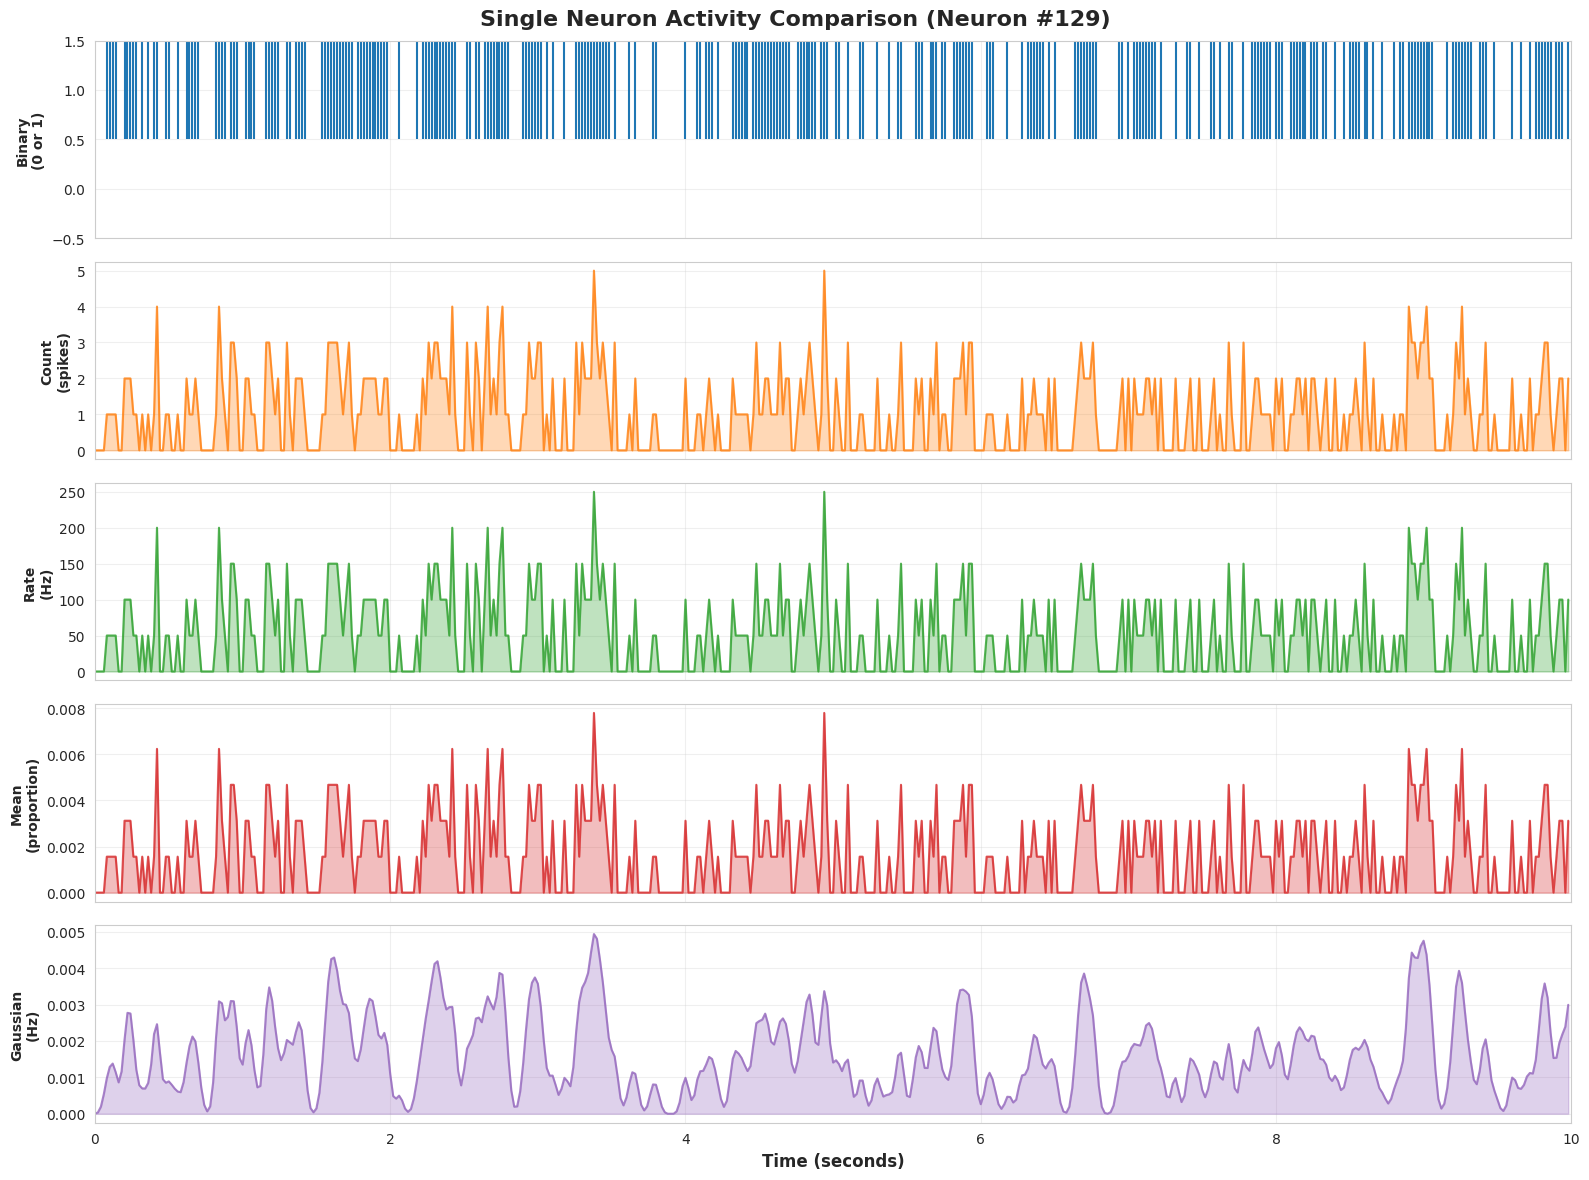

In [ ]:
# Find the most active neuron (highest mean firing rate)
firing_rates = np.array(datasets['rate'].x.mean(axis=1)).flatten()
most_active_neuron = np.argmax(firing_rates)
print(f"Most active neuron: #{most_active_neuron}")
print(f"Mean firing rate: {firing_rates[most_active_neuron]:.2f} Hz")

# Select a 10-second window to visualize (middle of recording)
start_time = datasets['binary'].x.shape[1] // 2
duration_samples = target_fs * 10  # 10 seconds at target_fs
end_time = start_time + duration_samples

# Create time axis in seconds
time_axis = np.arange(duration_samples) / target_fs

# Create multi-panel figure
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Single Neuron Activity Comparison (Neuron #{most_active_neuron})', 
             fontsize=16, fontweight='bold')

method_colors = {
    'binary': '#1f77b4',
    'count': '#ff7f0e',
    'rate': '#2ca02c',
    'mean': '#d62728',
    'gaussian': '#9467bd'
}

for idx, method in enumerate(methods):
    ax = axes[idx]
    
    # Extract neuron activity for this window
    activity = datasets[method].x[most_active_neuron, start_time:end_time].toarray().flatten()
    
    # Plot based on method type
    if method == 'binary':
        # Raster plot for binary
        spike_times = time_axis[activity > 0]
        ax.eventplot([spike_times], colors=[method_colors[method]], linewidths=1.5)
        ax.set_ylabel('Binary\n(0 or 1)', fontweight='bold')
        ax.set_ylim([-0.5, 1.5])
    else:
        # Line plot for continuous methods
        ax.plot(time_axis, activity, color=method_colors[method], linewidth=1.5, alpha=0.8)
        ax.fill_between(time_axis, 0, activity, alpha=0.3, color=method_colors[method])
        
        if method == 'count':
            ax.set_ylabel('Count\n(spikes)', fontweight='bold')
        elif method == 'rate':
            ax.set_ylabel('Rate\n(Hz)', fontweight='bold')
        elif method == 'mean':
            ax.set_ylabel('Mean\n(proportion)', fontweight='bold')
        elif method == 'gaussian':
            ax.set_ylabel('Gaussian\n(Hz)', fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 10])

axes[-1].set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Compare Multiple Neurons Side-by-Side

Now let's compare several neurons to see how different activity patterns are represented.

Selected neurons:
  Neuron #129: 57.29 Hz
  Neuron #98: 7.50 Hz
  Neuron #237: 3.48 Hz
  Neuron #227: 1.41 Hz


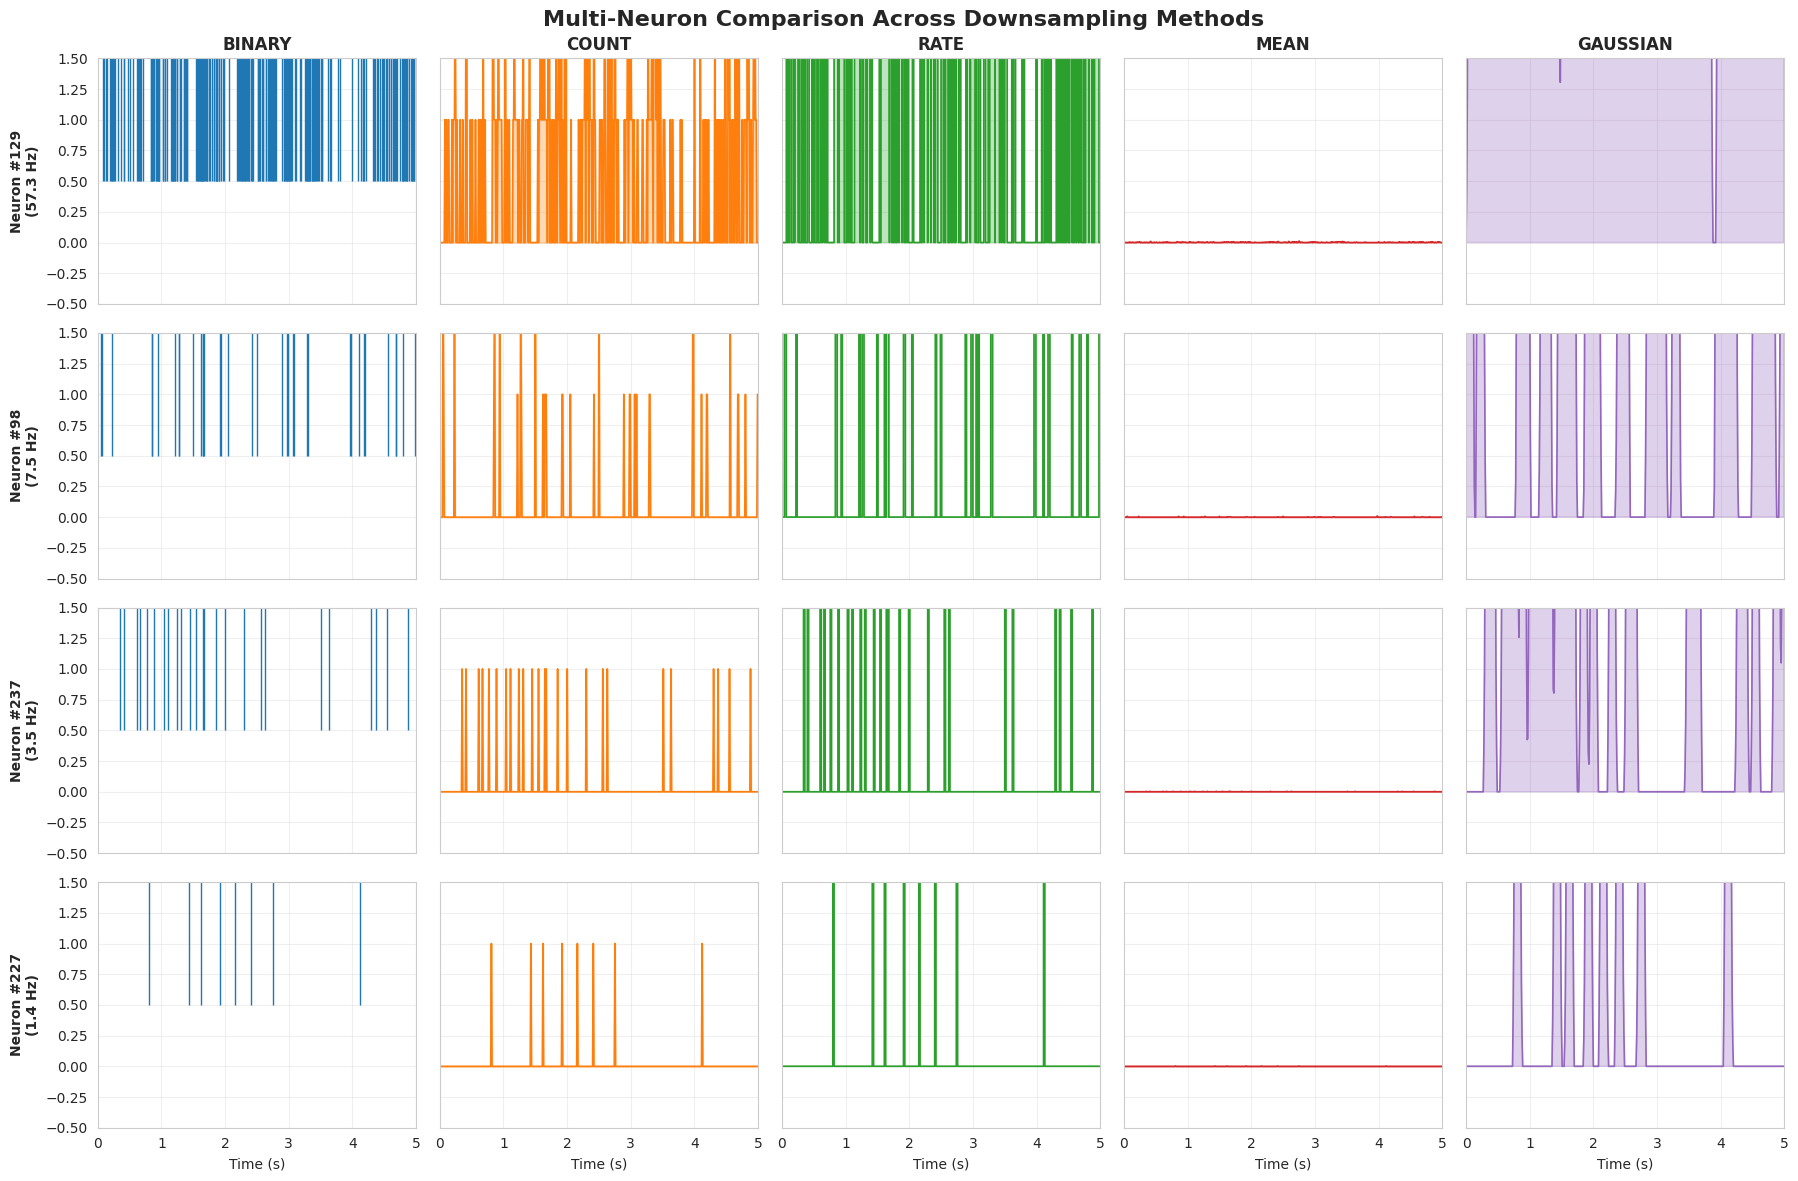

In [ ]:
# Select neurons with different activity levels
sorted_neurons = np.argsort(firing_rates)[::-1]  # Sort by firing rate descending
selected_neurons = [
    sorted_neurons[0],      # Highest firing rate
    sorted_neurons[len(sorted_neurons)//4],   # Upper quartile
    sorted_neurons[len(sorted_neurons)//2],   # Median
    sorted_neurons[3*len(sorted_neurons)//4], # Lower quartile
]

print("Selected neurons:")
for i, neuron_idx in enumerate(selected_neurons):
    print(f"  Neuron #{neuron_idx}: {firing_rates[neuron_idx]:.2f} Hz")

# Shorter window for detailed comparison
window_duration = 5  # seconds
window_samples = target_fs * window_duration
start_window = start_time
end_window = start_window + window_samples
time_window = np.arange(window_samples) / target_fs

# Pre-calculate max values for each neuron across all methods (for consistent y-scaling)
neuron_max_values = []
for neuron_idx in selected_neurons:
    max_val = 0
    for method in methods:
        if method != 'binary':  # Skip binary since it's always 0-1
            activity = datasets[method].x[neuron_idx, start_window:end_window].toarray().flatten()
            max_val = max(max_val, np.max(activity))
    neuron_max_values.append(max_val * 1.1)  # Add 10% padding

# Create comparison figure
fig, axes = plt.subplots(len(selected_neurons), len(methods), 
                         figsize=(18, 12), sharex=True)
fig.suptitle('Multi-Neuron Comparison Across Downsampling Methods (Same Y-Scale per Row)', 
             fontsize=16, fontweight='bold')

# Add column titles
for col_idx, method in enumerate(methods):
    axes[0, col_idx].set_title(method.upper(), fontsize=12, fontweight='bold')

for row_idx, neuron_idx in enumerate(selected_neurons):
    for col_idx, method in enumerate(methods):
        ax = axes[row_idx, col_idx]
        
        # Extract activity
        activity = datasets[method].x[neuron_idx, start_window:end_window].toarray().flatten()
        
        # Plot
        if method == 'binary':
            spike_times = time_window[activity > 0]
            ax.eventplot([spike_times], colors=[method_colors[method]], linewidths=1)
            ax.set_ylim([-0.5, 1.5])
        else:
            ax.plot(time_window, activity, color=method_colors[method], linewidth=1.2)
            ax.fill_between(time_window, 0, activity, alpha=0.3, color=method_colors[method])
            # Set consistent y-limit across all non-binary methods for this neuron
            ax.set_ylim([0, neuron_max_values[row_idx]])
        
        # Row labels (neuron info)
        if col_idx == 0:
            ax.set_ylabel(f'Neuron #{neuron_idx}\n({firing_rates[neuron_idx]:.1f} Hz)', 
                         fontsize=10, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, window_duration])

# X-axis label on bottom row
for col_idx in range(len(methods)):
    axes[-1, col_idx].set_xlabel('Time (s)', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Statistical Properties Comparison

Let's quantify the differences between methods by analyzing their statistical properties.

Statistical Properties Comparison
              mean        std         max  min  sparsity    dtype  \
binary    0.059486   0.236533           1    0  0.940514    uint8   
count     0.062704   0.256293           5    0  0.940514   uint16   
rate      6.270249   25.62911   499.99649  0.0  0.940514  float32   
mean      0.000196     0.0008      0.0156  0.0  0.940514  float32   
gaussian   6.25349  13.008772  402.951569  0.0  0.596654  float32   

         mean_firing_rate nonzero_count  
binary           0.059486       2823162  
count            0.062704       2823162  
rate             6.270249       2823162  
mean             0.000196       2823162  
gaussian          6.25349      19142398  


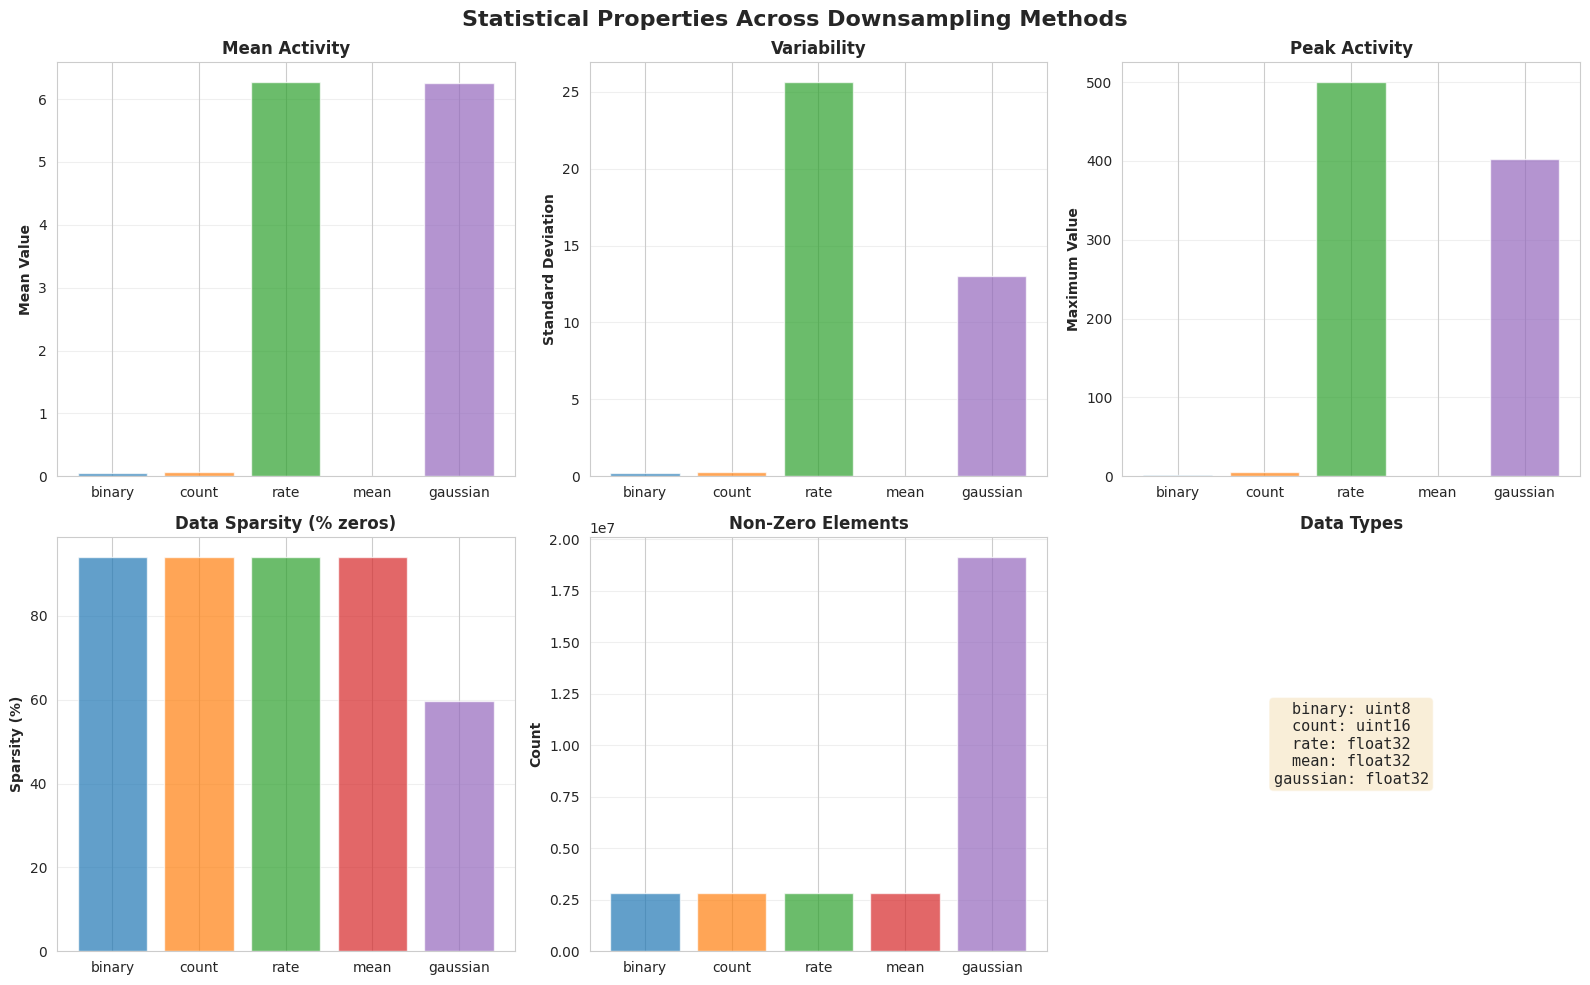

In [ ]:
# Calculate statistics for each method
stats = {}

for method in methods:
    x_data = datasets[method].x
    x_dense = x_data.toarray()
    
    stats[method] = {
        'mean': np.mean(x_dense),
        'std': np.std(x_dense),
        'max': np.max(x_dense),
        'min': np.min(x_dense),
        'sparsity': 1 - (x_data.nnz / (x_data.shape[0] * x_data.shape[1])),
        'dtype': str(x_data.dtype),
        'mean_firing_rate': np.mean(x_dense),  # For rate methods this is Hz
        'nonzero_count': x_data.nnz,
    }

# Create comparison table
import pandas as pd

stats_df = pd.DataFrame(stats).T
stats_df = stats_df.round(4)

print("Statistical Properties Comparison")
print("=" * 80)
print(stats_df)
print("=" * 80)

# Visualize key statistics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Statistical Properties Across Downsampling Methods', fontsize=16, fontweight='bold')

# Mean values
ax = axes[0, 0]
values = [stats[m]['mean'] for m in methods]
bars = ax.bar(methods, values, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Mean Value', fontweight='bold')
ax.set_title('Mean Activity', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Standard deviation
ax = axes[0, 1]
values = [stats[m]['std'] for m in methods]
bars = ax.bar(methods, values, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Standard Deviation', fontweight='bold')
ax.set_title('Variability', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Max values
ax = axes[0, 2]
values = [stats[m]['max'] for m in methods]
bars = ax.bar(methods, values, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Maximum Value', fontweight='bold')
ax.set_title('Peak Activity', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Sparsity (proportion of zeros)
ax = axes[1, 0]
values = [stats[m]['sparsity'] * 100 for m in methods]
bars = ax.bar(methods, values, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Sparsity (%)', fontweight='bold')
ax.set_title('Data Sparsity (% zeros)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Non-zero elements
ax = axes[1, 1]
values = [stats[m]['nonzero_count'] for m in methods]
bars = ax.bar(methods, values, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Non-Zero Elements', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Data types
ax = axes[1, 2]
dtypes = [stats[m]['dtype'] for m in methods]
ax.text(0.5, 0.5, '\n'.join([f"{m}: {stats[m]['dtype']}" for m in methods]),
        ha='center', va='center', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Data Types', fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Population Activity Heatmaps

Visualize the entire population of neurons over time for each downsampling method.

In [ ]:
# Select a 30-second window for population visualization
pop_duration = 30  # seconds
pop_samples = target_fs * pop_duration
pop_start = start_time
pop_end = pop_start + pop_samples

# Create heatmaps for each method
fig, axes = plt.subplots(1, len(methods), figsize=(20, 8))
fig.suptitle('Population Activity Heatmaps (All Neurons, 30 seconds)', 
             fontsize=16, fontweight='bold')

for idx, method in enumerate(methods):
    ax = axes[idx]
    
    # Extract population data
    pop_data = datasets[method].x[:, pop_start:pop_end].toarray()
    
    # Create heatmap with method-specific colormap
    if method == 'binary':
        # Binary: just black and white
        im = ax.imshow(pop_data, aspect='auto', cmap='binary', 
                      interpolation='nearest', origin='lower')
        vmax = 1
    elif method == 'gaussian':
        # Gaussian: smooth colormap
        im = ax.imshow(pop_data, aspect='auto', cmap='viridis', 
                      interpolation='bilinear', origin='lower')
        vmax = np.percentile(pop_data[pop_data > 0], 95) if pop_data.max() > 0 else 1
        im.set_clim(0, vmax)
    else:
        # Other methods
        im = ax.imshow(pop_data, aspect='auto', cmap='hot', 
                      interpolation='nearest', origin='lower')
        vmax = np.percentile(pop_data[pop_data > 0], 95) if pop_data.max() > 0 else 1
        im.set_clim(0, vmax)
    
    ax.set_title(method.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Neuron Index', fontweight='bold')
    
    # Set x-axis ticks in seconds
    xticks = np.arange(0, pop_samples, target_fs * 5)  # Every 5 seconds
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{int(t/target_fs)}' for t in xticks])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if method == 'rate' or method == 'gaussian':
        cbar.set_label('Hz', rotation=270, labelpad=15)
    elif method == 'count':
        cbar.set_label('Spikes', rotation=270, labelpad=15)
    elif method == 'mean':
        cbar.set_label('Proportion', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## 6. Firing Rate Distributions

Compare how each method represents the distribution of neural activity across the population.

In [ ]:
# Calculate per-neuron mean activity for each method
neuron_means = {}
for method in methods:
    neuron_means[method] = np.array(datasets[method].x.mean(axis=1)).flatten()

# Create distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Activity Distribution Across Methods', fontsize=16, fontweight='bold')

# Histograms
ax = axes[0, 0]
for method in methods:
    values = neuron_means[method]
    ax.hist(values, bins=50, alpha=0.5, label=method, color=method_colors[method], density=True)
ax.set_xlabel('Mean Activity per Neuron', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Activity Distribution (All Methods)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Individual method histograms
for idx, method in enumerate(['binary', 'count', 'rate']):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    ax = axes[row, col]
    
    values = neuron_means[method]
    ax.hist(values, bins=50, color=method_colors[method], alpha=0.7, edgecolor='black')
    ax.set_xlabel(f'Mean {method.capitalize()}', fontweight='bold')
    ax.set_ylabel('Neuron Count', fontweight='bold')
    ax.set_title(f'{method.upper()} Distribution', fontweight='bold')
    ax.grid(alpha=0.3)

for idx, method in enumerate(['mean', 'gaussian']):
    row = 1
    col = idx + 1
    ax = axes[row, col]
    
    values = neuron_means[method]
    ax.hist(values, bins=50, color=method_colors[method], alpha=0.7, edgecolor='black')
    ax.set_xlabel(f'Mean {method.capitalize()}', fontweight='bold')
    ax.set_ylabel('Neuron Count', fontweight='bold')
    ax.set_title(f'{method.upper()} Distribution', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for comparison
fig, ax = plt.subplots(figsize=(12, 6))
data_for_box = [neuron_means[m] for m in methods]
bp = ax.boxplot(data_for_box, labels=[m.upper() for m in methods], patch_artist=True)

# Color the boxes
for patch, method in zip(bp['boxes'], methods):
    patch.set_facecolor(method_colors[method])
    patch.set_alpha(0.7)

ax.set_ylabel('Mean Activity per Neuron', fontsize=12, fontweight='bold')
ax.set_title('Activity Distribution Comparison (Box Plots)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Performance and Memory Comparison

Analyze the computational efficiency and memory requirements of each method.

In [ ]:
# Calculate memory usage and performance metrics
import sys

performance = {}

for method in methods:
    x_data = datasets[method].x
    
    # Memory usage
    # For sparse matrices: data + indices + indptr arrays
    data_bytes = x_data.data.nbytes if hasattr(x_data, 'data') else 0
    indices_bytes = x_data.indices.nbytes if hasattr(x_data, 'indices') else 0
    indptr_bytes = x_data.indptr.nbytes if hasattr(x_data, 'indptr') else 0
    total_bytes = data_bytes + indices_bytes + indptr_bytes
    
    # Dense equivalent size
    dense_bytes = x_data.shape[0] * x_data.shape[1] * x_data.dtype.itemsize
    
    # Sparsity
    sparsity = 1 - (x_data.nnz / (x_data.shape[0] * x_data.shape[1]))
    
    # Compression ratio
    compression_ratio = dense_bytes / total_bytes if total_bytes > 0 else 0
    
    performance[method] = {
        'sparse_size_mb': total_bytes / (1024**2),
        'dense_size_mb': dense_bytes / (1024**2),
        'compression_ratio': compression_ratio,
        'sparsity_pct': sparsity * 100,
        'nnz_elements': x_data.nnz,
        'dtype_bytes': x_data.dtype.itemsize,
    }

# Create performance DataFrame
perf_df = pd.DataFrame(performance).T
perf_df = perf_df.round(3)

print("Performance and Memory Comparison")
print("=" * 90)
print(perf_df)
print("=" * 90)

# Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance and Memory Analysis', fontsize=16, fontweight='bold')

# Memory usage (sparse vs dense)
ax = axes[0, 0]
x_pos = np.arange(len(methods))
width = 0.35
sparse_sizes = [performance[m]['sparse_size_mb'] for m in methods]
dense_sizes = [performance[m]['dense_size_mb'] for m in methods]

bars1 = ax.bar(x_pos - width/2, sparse_sizes, width, label='Sparse', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, dense_sizes, width, label='Dense', alpha=0.8)

ax.set_ylabel('Memory (MB)', fontweight='bold')
ax.set_title('Memory Usage Comparison', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([m.upper() for m in methods], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Color bars by method
for i, (bar, method) in enumerate(zip(bars1, methods)):
    bar.set_color(method_colors[method])

# Compression ratio
ax = axes[0, 1]
ratios = [performance[m]['compression_ratio'] for m in methods]
bars = ax.bar(methods, ratios, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Compression Ratio', fontweight='bold')
ax.set_title('Compression Efficiency\n(Dense / Sparse)', fontweight='bold')
ax.set_xticklabels([m.upper() for m in methods], rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ratio:.1f}x', ha='center', va='bottom', fontweight='bold')

# Sparsity percentage
ax = axes[1, 0]
sparsity = [performance[m]['sparsity_pct'] for m in methods]
bars = ax.bar(methods, sparsity, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Sparsity (%)', fontweight='bold')
ax.set_title('Data Sparsity', fontweight='bold')
ax.set_xticklabels([m.upper() for m in methods], rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 100])

# Data type bytes
ax = axes[1, 1]
dtype_bytes = [performance[m]['dtype_bytes'] for m in methods]
bars = ax.bar(methods, dtype_bytes, color=[method_colors[m] for m in methods], alpha=0.7)
ax.set_ylabel('Bytes per Element', fontweight='bold')
ax.set_title('Data Type Size', fontweight='bold')
ax.set_xticklabels([m.upper() for m in methods], rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, dtype_byte in zip(bars, dtype_bytes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{dtype_byte} B', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Summary and Recommendations

### Key Differences Between Methods:

1. **Binary** (`uint8`, values: 0 or 1)
   - Preserves spike timing
   - Most sparse representation
   - Loses spike count information within bins
   - Best for: Spike timing analysis, memory-constrained applications

2. **Count** (`uint16`, values: 0 to max_count)
   - Preserves exact spike counts
   - More dense than binary
   - Raw spike counts (not normalized)
   - Best for: Applications needing exact spike counts

3. **Rate** (`float32`, values: Hz)
   - Firing rate in spikes/second
   - Bin-size independent (normalized by time)
   - Directly comparable across different downsample rates
   - Best for: Rate-based analyses, comparing different temporal resolutions

4. **Mean** (`float32`, values: 0-1)
   - Spike proportion (normalized by bin samples)
   - Values in [0, 1] range
   - Similar to binary but continuous
   - Best for: Normalized spike density, ML applications expecting [0,1] range

5. **Gaussian** (`float32`, values: Hz)
   - Smooth firing rate estimate
   - Temporal smoothing mimics biological integration
   - Similar to calcium imaging signals
   - Least sparse (more non-zero values due to kernel spread)
   - Best for: Smooth dynamics, downstream neural integration modeling

### When to Use Each Method:

- **Spike timing critical**: Binary
- **Exact counts needed**: Count
- **Firing rate analysis**: Rate or Gaussian
- **Normalized comparisons**: Mean or Rate
- **Smooth dynamics**: Gaussian
- **Maximum memory efficiency**: Binary